ParameterSet(dt              0.04
T             600.00
delay         200.00
slope_time      2.00
Vthres          0.00
Tref            2.00
R               0.89
tRC            33.00
Vrest         -58.00
EL            -62.00
Ew            -62.00
Vreset        -52.00
VTdelta         3.56
VT            -48.44
Del             5.20
tau_w          26.80
a               1.00
b              16.20
dtype: float64)


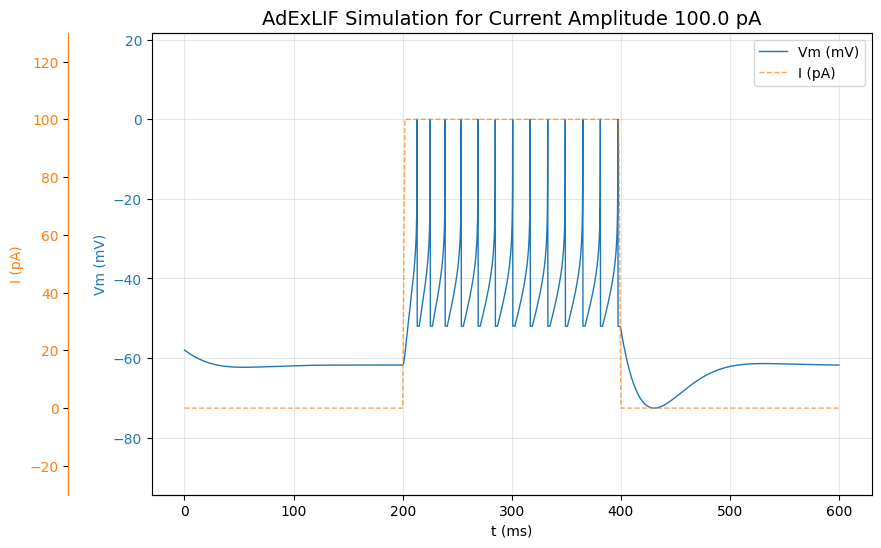

(<Figure size 1000x600 with 2 Axes>,
 [<Axes: xlabel='t (ms)', ylabel='Vm (mV)'>,
  <Axes: title={'center': 'AdExLIF Simulation for Current Amplitude 100.0 pA'}, ylabel='I (pA)'>])

In [5]:
# set python path
import sys
sys.path.append('/home/jordan/repos/neuron_fitting')
from adexlif_ot_ficurve.adexlif_model import *

neuron_type = 'ipc'

# bank = default_parameter_bank(neuron_type)

# preliminary run ipc:
# dt	0.04
# T	600.0
# delay	200.0
# slope_time	2.0
# Vthres	0.0
# Tref	2.0
# R	0.8943399643033411
# tRC	33.26108193495312
# Vrest	-58.908752555873015
# EL	-62.07470084210594
# Ew	-62.07470084210594
# Vreset	-52.16148652420988
# VTdelta	3.56673591948977
# VT	-48.594750604720105
# Del	5.204685360901683
# tau_w	26.82658697945378
# a	1.0028301441429521
# b	16.270892119169826
bank = ParameterBank(
    parameters={
        "dt": IndependentScalarParameter(0.04),
        "T": IndependentScalarParameter(600),
        "delay": IndependentScalarParameter(200.0),
        "slope_time": IndependentScalarParameter(2.0),
        "Vthres": IndependentScalarParameter(0.0),
        "Tref": IndependentScalarParameter(2.0),
        "R": IndependentScalarParameter(0.89),
        "tRC": IndependentScalarParameter(33),
        "Vrest": IndependentScalarParameter(-58),
        "EL": IndependentScalarParameter(-62),
        "Ew": DerivedScalarParameter(lambda p: p["EL"]),
        "Vreset": IndependentScalarParameter(-52),
        "VTdelta": IndependentScalarParameter(3.56),
        "VT": DerivedScalarParameter(lambda p: p["Vreset"] + p["VTdelta"]),
        "Del": IndependentScalarParameter(5.2),
        "tau_w": IndependentScalarParameter(26.8),
        "a": IndependentScalarParameter(1.0),
        "b": IndependentScalarParameter(16.2),
    },
    constraints=[
        lambda p: p["a"] * p["R"] - p["tRC"] / p["tau_w"] < 0
    ],  # restrict to SN bifurcation
    array_mode=False,
)


print(bank.get_default_values())

exp = AdExExperiment(param_dict=bank.get_default_values())
exp.plot_run(current_amplitude=100)

# points in data: 25


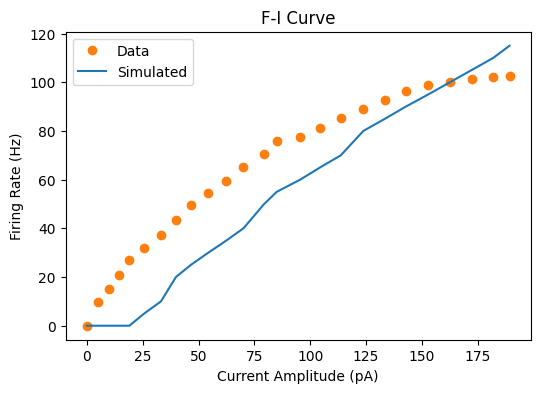

In [6]:
data = get_goddard_ficurve_data(n_thin=1)
current_amp_grid = data[neuron_type]["current"]
observed_freqs = data[neuron_type]["frequency"]
print("# points in data:", len(current_amp_grid))

experiment = AdExExperiment(param_dict=bank.get_default_values())
fig, ax = experiment.plot_f_i_curve(current_amplitudes=current_amp_grid, data=observed_freqs, figsize=(6, 4))
plt.show()